<a href="https://colab.research.google.com/github/Satishpk15/Python/blob/main/Paandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.DataFrame({
    'Transaction_ID': [101, 102, 103, 104, 104, 105, 106],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Grocery', 'Grocery', 'Electronics', 'Clothing'],
    'Branch': ['Hyderabad', 'Hyderabad', 'Bangalore', 'Bangalore', 'Bangalore', 'Hyderabad', 'Chennai'],
    'Coffee_Type': ['Latte', 'Espresso', 'Latte', 'Cappuccino', 'Cappuccino', 'Mocha', 'Latte'],
    'Sales': [25000, 5000, 18000, 2000, 2000, 22000, 7000],
    'Salary': [50000, 42000, 60000, 39000, 39000, 65000, 45000]
})

print(df)

   Transaction_ID     Category     Branch Coffee_Type  Sales  Salary
0             101  Electronics  Hyderabad       Latte  25000   50000
1             102     Clothing  Hyderabad    Espresso   5000   42000
2             103  Electronics  Bangalore       Latte  18000   60000
3             104      Grocery  Bangalore  Cappuccino   2000   39000
4             104      Grocery  Bangalore  Cappuccino   2000   39000
5             105  Electronics  Hyderabad       Mocha  22000   65000
6             106     Clothing    Chennai       Latte   7000   45000


In [ ]:
df_duplicates_remove = df.drop_duplicates()

In [ ]:
print(df_duplicates_remove)

   Transaction_ID     Category     Branch Coffee_Type  Sales  Salary
0             101  Electronics  Hyderabad       Latte  25000   50000
1             102     Clothing  Hyderabad    Espresso   5000   42000
2             103  Electronics  Bangalore       Latte  18000   60000
3             104      Grocery  Bangalore  Cappuccino   2000   39000
5             105  Electronics  Hyderabad       Mocha  22000   65000
6             106     Clothing    Chennai       Latte   7000   45000


In [ ]:
df_group = df.groupby("Category").sum()
print(df_group)

             Transaction_ID                       Branch  \
Category                                                   
Clothing                208             HyderabadChennai   
Electronics             309  HyderabadBangaloreHyderabad   
Grocery                 208           BangaloreBangalore   

                      Coffee_Type  Sales  Salary  
Category                                          
Clothing            EspressoLatte  12000   87000  
Electronics       LatteLatteMocha  65000  175000  
Grocery      CappuccinoCappuccino   4000   78000  


In [ ]:
df_group_electronic = df.groupby("Category").count()
print(df_group_electronic)
# print(df_group_electronic['Electronics'])

             Transaction_ID  Branch  Coffee_Type  Sales  Salary
Category                                                       
Clothing                  2       2            2      2       2
Electronics               3       3            3      3       3
Grocery                   2       2            2      2       2


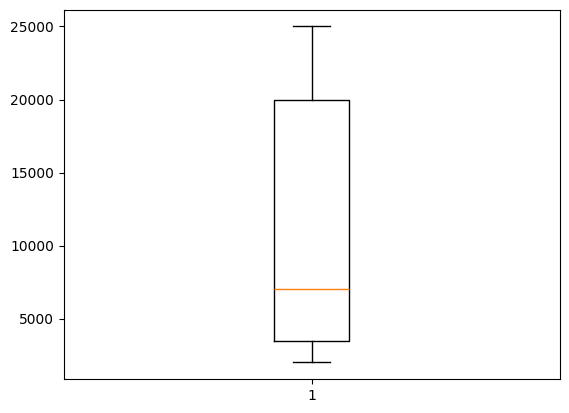

In [ ]:
plt.boxplot(df['Sales'])
plt.show()

In [ ]:
result = df.groupby("Category").agg(Avg_Salary=('Salary', 'mean'))
print(result)

               Avg_Salary
Category                 
Clothing     43500.000000
Electronics  58333.333333
Grocery      39000.000000


You are working with the Titanic dataset, which has 891 rows and columns including sex, pclass, age, fare, embarked, and survived. The dataset has 177 missing values in the age column (approximately 20% of records).

Your task is to write a complete Python script using Pandas that performs the following data analysis pipeline:

Requirements:

Load the Titanic dataset from a CSV file called titanic.csv using read_csv

Filter passengers who are female AND in pclass 1 or pclass 2 (use isin for the pclass check)

From this filtered group, fill missing age values with the value 30 using fillna

Sort the filtered DataFrame by fare in descending order, then reset the index so the index values are sequential from 0

Add a new column called fare_group that assigns the string 'high' to all rows (you may assign a constant string value to the new column)

Save the final result to a new CSV file called female_upper_class.csv
Constraints:

Use only Pandas operations covered: read_csv, boolean filtering with &, isin, fillna, sort_values, reset_index, adding a new column, and to_csv
Handle missing values with fillna only — leave dropna out of the solution
All conditions must be wrapped in parentheses when combining with &


In [ ]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
filtered_data = df[(df['sex']=='female') & (df['pclass'].isin([1,2]))].copy()

print(filtered_data)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
1           1       1  female  38.0      1      0  71.2833        C   First   
3           1       1  female  35.0      1      0  53.1000        S   First   
9           1       2  female  14.0      1      0  30.0708        C  Second   
11          1       1  female  58.0      0      0  26.5500        S   First   
15          1       2  female  55.0      0      0  16.0000        S  Second   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
871         1       1  female  47.0      1      1  52.5542        S   First   
874         1       2  female  28.0      1      0  24.0000        C  Second   
879         1       1  female  56.0      0      1  83.1583        C   First   
880         1       2  female  25.0      0      1  26.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   

       who  adult_male deck  embark_town alive  alo

In [ ]:
filtered_data["age"] = filtered_data["age"].fillna(30)

In [ ]:
filtered_data = filtered_data.sort_values(by="fare",ascending = False)
print(filtered_data)

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
258         1       1  female  35.0      0      0  512.3292        C   First   
88          1       1  female  23.0      3      2  263.0000        S   First   
341         1       1  female  24.0      3      2  263.0000        S   First   
311         1       1  female  18.0      2      2  262.3750        C   First   
742         1       1  female  21.0      2      2  262.3750        C   First   
..        ...     ...     ...   ...    ...    ...       ...      ...     ...   
458         1       2  female  50.0      0      0   10.5000        S  Second   
526         1       2  female  50.0      0      0   10.5000        S  Second   
516         1       2  female  34.0      0      0   10.5000        S  Second   
717         1       2  female  27.0      0      0   10.5000        S  Second   
772         0       2  female  57.0      0      0   10.5000        S  Second   

       who  adult_male deck  embark_tow

In [ ]:
filtered_data = filtered_data.reset_index(drop=True)
print(filtered_data)

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
0           1       1  female  35.0      0      0  512.3292        C   First   
1           1       1  female  23.0      3      2  263.0000        S   First   
2           1       1  female  24.0      3      2  263.0000        S   First   
3           1       1  female  18.0      2      2  262.3750        C   First   
4           1       1  female  21.0      2      2  262.3750        C   First   
..        ...     ...     ...   ...    ...    ...       ...      ...     ...   
165         1       2  female  50.0      0      0   10.5000        S  Second   
166         1       2  female  50.0      0      0   10.5000        S  Second   
167         1       2  female  34.0      0      0   10.5000        S  Second   
168         1       2  female  27.0      0      0   10.5000        S  Second   
169         0       2  female  57.0      0      0   10.5000        S  Second   

       who  adult_male deck  embark_tow

In [ ]:
filtered_data["fare_group"]="high"
print(filtered_data)

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
0           1       1  female  35.0      0      0  512.3292        C   First   
1           1       1  female  23.0      3      2  263.0000        S   First   
2           1       1  female  24.0      3      2  263.0000        S   First   
3           1       1  female  18.0      2      2  262.3750        C   First   
4           1       1  female  21.0      2      2  262.3750        C   First   
..        ...     ...     ...   ...    ...    ...       ...      ...     ...   
165         1       2  female  50.0      0      0   10.5000        S  Second   
166         1       2  female  50.0      0      0   10.5000        S  Second   
167         1       2  female  34.0      0      0   10.5000        S  Second   
168         1       2  female  27.0      0      0   10.5000        S  Second   
169         0       2  female  57.0      0      0   10.5000        S  Second   

       who  adult_male deck  embark_tow

In [ ]:
filtered_data.to_csv("female_upper_class.csv", index = False)

You are analyzing a cleaned version of the Titanic dataset. The dataset has the following relevant columns: Pclass (1, 2, or 3), gender (male or female), Survived (0 or 1), age (numeric, fully populated), and fare (numeric).

A product team at a data consultancy wants a summary table and a written insight report. Your task is to produce both using only pandas group by and aggregation techniques.

Task:

Produce a pandas DataFrame called summary that contains one row per unique combination of Pclass and gender, with these columns:


total_passengers — count of passengers in that group

survivors — total number who survived (sum of Survived)

survival_rate — mean of Survived (proportion who survived)

avg_age — mean age of passengers in that group

max_fare — maximum fare paid in that group

Then, based on your output, write 3 brief observations (1–2 sentences each) about patterns you notice in the data.

Constraints:

Use a single .agg() call on a group by — combine all statistics in one operation
Call .reset_index() so that Pclass and gender become regular columns
Your written observations must be grounded in specific values from the output table


In [ ]:
import pandas as pd
import seaborn as sns

df1 = sns.load_dataset("titanic")
df1 = df[["pclass", "sex", "survived", "age", "fare"]].dropna()

summary = df1.groupby(['pclass', 'sex']).agg(total_passengers=("survived","count"),
                                                survivors = ("survived", "sum"),
                                                survival_rate=("survived","mean"),
                                                avg_age= ("age","mean"),
                                                max_fare = ("fare","max")).reset_index()
print(summary)



   pclass     sex  total_passengers  survivors  survival_rate    avg_age  \
0       1  female                85         82       0.964706  34.611765   
1       1    male               101         40       0.396040  41.281386   
2       2  female                74         68       0.918919  28.722973   
3       2    male                99         15       0.151515  30.740707   
4       3  female               102         47       0.460784  21.750000   
5       3    male               253         38       0.150198  26.507589   

   max_fare  
0  512.3292  
1  512.3292  
2   65.0000  
3   73.5000  
4   46.9000  
5   56.4958  


Problem Statement: You are a junior data analyst at a retail company. Your manager hands you a CSV file containing daily sales records for three product categories — Electronics, Clothing, and Groceries — with the following columns: date, category, units_sold, revenue, and discount_pct. Your task is to perform a targeted EDA to answer three specific business questions:

How are units_sold distributed overall, and does the distribution differ by category?

Are there any outlier revenue values in any product category?

Do units_sold and revenue move together (and in which direction)?

Write a Python EDA script using Seaborn and/or Matplotlib that produces the following four plots:

A histogram of units_sold with 20 bins.

The same histogram broken down by category using hue.

A box plot of revenue grouped by category.

A scatter plot of units_sold vs. revenue colored by category.

You must also programmatically compute and print the IQR-based outlier bounds for the revenue column (across all categories combined).

Constraints & Requirements:

Use Seaborn (sns) and/or Matplotlib (plt) for all plots.
Use Pandas .quantile() to compute Q1, Q3, IQR, and whisker bounds.
Do not use any external statistical libraries (e.g., scipy).
Each plot must have a title and axis labels.
The outlier computation must print the lower and upper whisker values.
You may use a synthetic DataFrame (created with pd.DataFrame) if you do not have access to a real CSV file.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)


dates = pd.date_range(start="2025-01-01", periods=45)

categories = ["Electronics", "Clothing", "Groceries"]

data = {
    "date": dates,
    "category": np.random.choice(categories, size=45),
    "units_sold": np.random.randint(5, 120, size=45),
    "revenue": np.random.randint(1000, 50000, size=45),
    "discount_pct": np.random.randint(0, 40, size=45)
}

df = pd.DataFrame(data)

print(df)

         date     category  units_sold  revenue  discount_pct
0  2025-01-01    Groceries          43    30127            39
1  2025-01-02  Electronics          22    41397            21
2  2025-01-03    Groceries           8    26851            26
3  2025-01-04    Groceries          93     2016            34
4  2025-01-05  Electronics          64    25253             0
5  2025-01-06  Electronics          18    25276            34
6  2025-01-07    Groceries         118    24247            36
7  2025-01-08     Clothing          13    25300            13
8  2025-01-09    Groceries          94     9529             2
9  2025-01-10    Groceries          57    18262             0
10 2025-01-11    Groceries           6    10268             4
11 2025-01-12    Groceries          88    22271            25
12 2025-01-13  Electronics          96    13185            13
13 2025-01-14    Groceries         115    22243            38
14 2025-01-15     Clothing          64    40099            26
15 2025-

In [ ]:
df.loc[2, "revenue"]=120000
df.loc[10, "revenue"]=950000
print(df)

         date     category  units_sold  revenue  discount_pct
0  2025-01-01    Groceries          43    30127            39
1  2025-01-02  Electronics          22    41397            21
2  2025-01-03    Groceries           8   120000            26
3  2025-01-04    Groceries          93     2016            34
4  2025-01-05  Electronics          64    25253             0
5  2025-01-06  Electronics          18    25276            34
6  2025-01-07    Groceries         118    24247            36
7  2025-01-08     Clothing          13    25300            13
8  2025-01-09    Groceries          94     9529             2
9  2025-01-10    Groceries          57    18262             0
10 2025-01-11    Groceries           6   950000             4
11 2025-01-12    Groceries          88    22271            25
12 2025-01-13  Electronics          96    13185            13
13 2025-01-14    Groceries         115    22243            38
14 2025-01-15     Clothing          64    40099            26
15 2025-

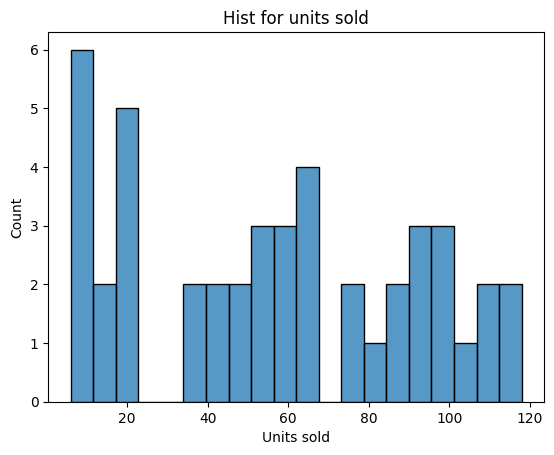

In [ ]:
sns.histplot(df["units_sold"], bins = 20)
plt.title("Hist for units sold")
plt.xlabel("Units sold")
plt.ylabel("Count")
plt.show()

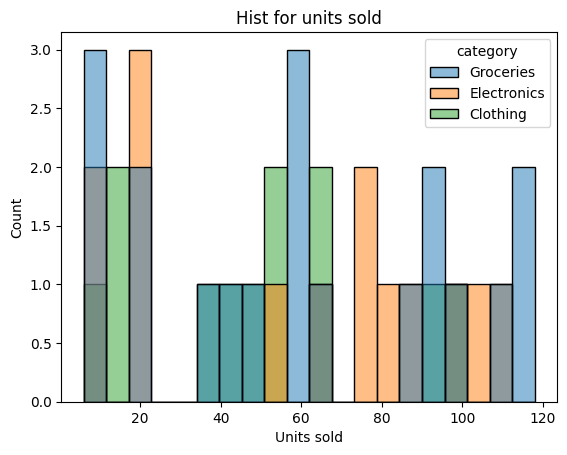

In [ ]:
sns.histplot(data= df, x ="units_sold",bins = 20, hue="category")
plt.title("Hist for units sold")
plt.xlabel("Units sold")
plt.ylabel("Count")
plt.show()

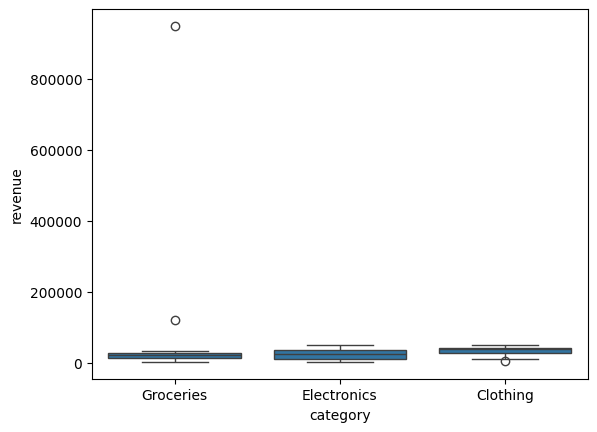

In [ ]:
sns.boxplot(data = df, x="category", y = "revenue")
plt.show()

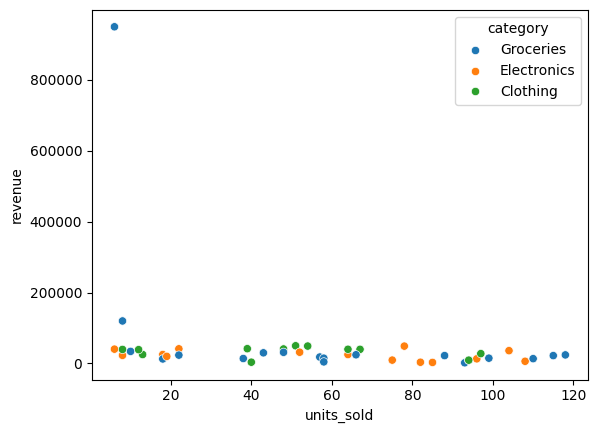

In [ ]:
sns.scatterplot(data=df, x="units_sold", y="revenue", hue="category")
plt.show()

In [ ]:
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3-Q1


lowest_fence = Q1-(1.5*IQR)
upper_fence = Q3+(1.5*IQR)
print(f"Lower bound = {lowest_fence} and Upper_bound = {upper_fence}")

Lower bound = -25325.0 and Upper_bound = 78651.0


Question 1: The Salary Aggregator (Moderate)
You have a DataFrame staff with columns: Department, Role, and Salary.
Write a single Pandas command using .groupby() and .agg() to find the Headcount (count), Lowest_Salary (min), and Highest_Salary (max) for each Department. Flatten the index.

Question 2: The Manual IQR Check (Moderate)
Given this list of test scores: [45, 55, 60, 65, 70, 75, 80, 85, 90, 150]
Use Pandas to load this list into a Series or DataFrame.
Programmatically calculate Q1, Q3, and the Upper/Lower fences.
Write a line of code to filter and print ONLY the rows/values that are considered outliers (greater than the upper fence or lower than the lower fence).

Question 3: Pair Plot Interpretation (Hard)
Load the built-in seaborn tips dataset (sns.load_dataset('tips')).
Generate a pair plot colored by the time of day (Lunch vs Dinner).
Look at the grid. Write two sentences explaining which two numerical variables show the strongest positive correlation based on the scatter plots you see. (Hint: Look for the tightest diagonal line of dots).
